 # House Price Prediction 
**Internship Project — Week 1**

Goal: predict house prices from property features (area, rooms, location-related flags, etc.) using regression

Dataset: Housing Prices Dataset (Kaggle) — 545 rows, 13 columns.

# Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# keeping the plots a bit bigger by default so they're readable
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [2]:
print("Rows, Columns:", df.shape)
df.info()

Rows, Columns: (545, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [3]:
# checking for missing values column by column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Since there is no missing values anywhere in this dataset.

# Task 2 — Data Cleaning

In [4]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("missing values left:", df.isnull().sum().sum())

missing values left: 0


In [5]:
# check + remove duplicate rows
print("duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()
df.shape

duplicate rows found: 0


(545, 13)

Now converting the categorical columns into numbers.

In [6]:
"""The yes/no columns are easy — just map them to 1 and 0. `furnishingstatus` has three
categories (furnished / semi-furnished / unfurnished) so that one needs proper one-hot
encoding."""

'The yes/no columns are easy — just map them to 1 and 0. `furnishingstatus` has three\ncategories (furnished / semi-furnished / unfurnished) so that one needs proper one-hot\nencoding.'

In [7]:
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})

df[binary_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [8]:
# one-hot encode furnishingstatus, drop_first to avoid the dummy variable trap
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True)

# get_dummies gives True/False, converting to 0/1 to keep things consistent
new_cols = ['furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
df[new_cols] = df[new_cols].astype(int)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


Now all columns are numeric .
So every columns have role in the price prediction 

In [9]:
df.columns.tolist()

['price',
 'area',
 'bedrooms',
 'bathrooms',
 'stories',
 'mainroad',
 'guestroom',
 'basement',
 'hotwaterheating',
 'airconditioning',
 'parking',
 'prefarea',
 'furnishingstatus_semi-furnished',
 'furnishingstatus_unfurnished']

# Task 3 — Model Building

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (436, 13)
Test size: (109, 13)


#### 1. Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

lin_preds = lin_model.predict(X_test)

mae_lin = mean_absolute_error(y_test, lin_preds)
rmse_lin = np.sqrt(mean_squared_error(y_test, lin_preds))
r2_lin = r2_score(y_test, lin_preds)

print("Linear Regression Results")
print("MAE :", round(mae_lin, 2))
print("RMSE:", round(rmse_lin, 2))
print("R2  :", round(r2_lin, 4))

Linear Regression Results
MAE : 970043.4
RMSE: 1324506.96
R2  : 0.6529


#### 2.Random Forest Regressor
Now trying a tree based model to see if it is actually better than Linear Regression .
As Linear Regression does'nt perfectly use linear function for special features ( like an extra bathroom matter more for bigger house ,etc)

In [12]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_preds)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_preds))
r2_rf = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R2  :", round(r2_rf, 4))

Random Forest Results
MAE : 1022560.05
RMSE: 1401496.84
R2  : 0.6114


In [13]:
# putting both side by side to compare directly
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae_lin, mae_rf],
    'RMSE': [rmse_lin, rmse_rf],
    'R2 Score': [r2_lin, r2_rf]
})
results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.022560e+06,1.401497e+06,0.611402


As seen Linear Regression actually edges out Random Forest here on R² (0.65 vs 0.61).

In fact, Linear Regression does come out better on R-squared score (0.65 compared to 0.61). I was initially surprised because of the greater "strength" of Random Forest; however, with such a small number of rows (~545), as well as fairly basic numeric and binary features, the Random Forest cannot find additional information that is not already accounted for in Linear Regression, and in all likelihood overfits to the training dataset a little. Another benefit of Linear Regression is its interpretability.

# Task 4 — Visualization

### Chart 1: Distribution of House Prices

In [14]:
import os

os.makedirs('charts', exist_ok=True)

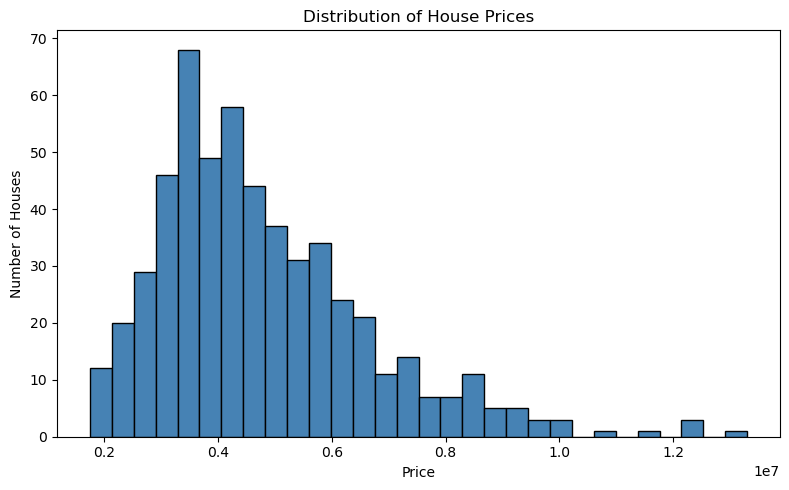

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('charts/1.price_distribution.png', dpi=150)
plt.show()

### Chart 2: Correlation Heatmap

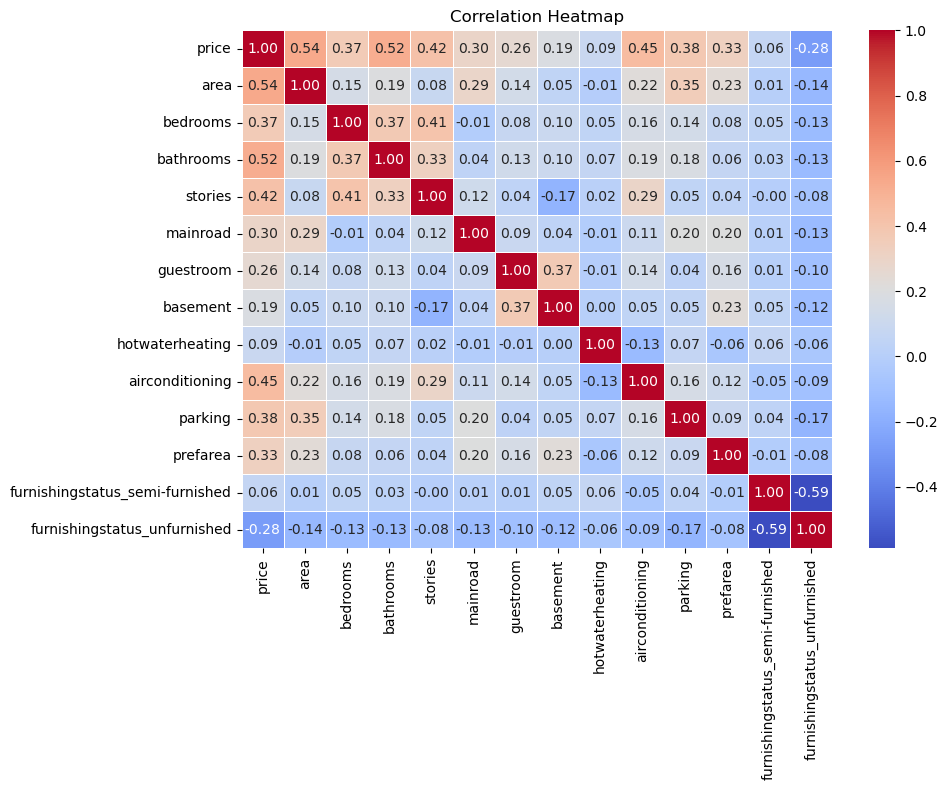

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

In [16]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('charts/2.correlation_heatmap.png', dpi=150)
plt.show()

# easier to read than the full heatmap - just price's correlation with everything else
df.corr()['price'].sort_values(ascending=False)

`area` has the strongest correlation with price (~0.54) and `bathrooms` (~0.52) and `airconditioning` (~0.45). `furnishingstatus_unfurnished` is negatively correlated, which makes sense — unfurnished houses tend to sell for less.

### Chart 3: Model Comparison - Linear Regression vs Random Forest (Line Graph)

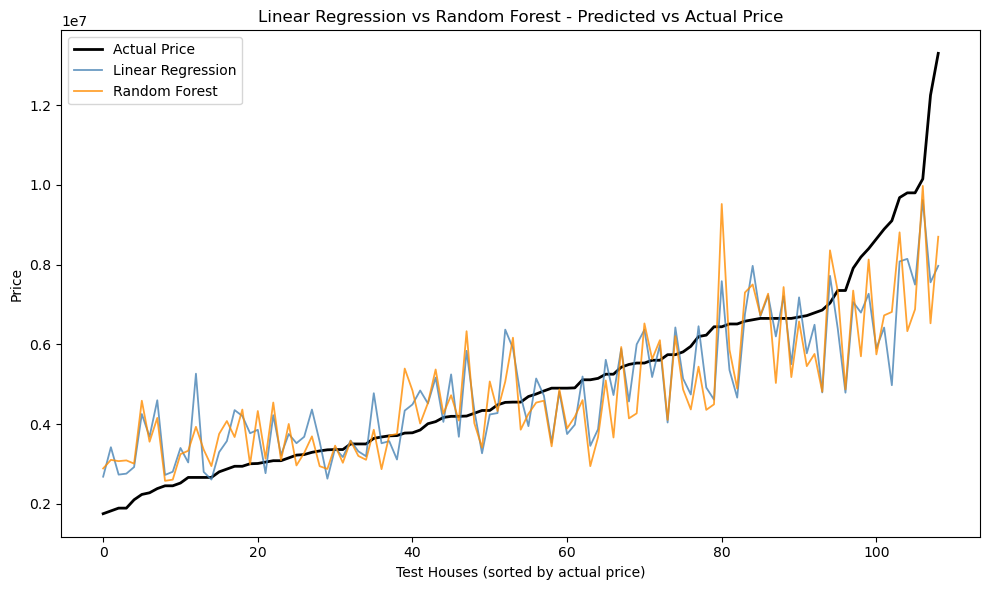

In [17]:
# Chart 3: Model Comparison - Linear Regression vs Random Forest (Line Graph)
order = np.argsort(y_test.values)
actual_sorted = y_test.values[order]
lin_sorted = lin_preds[order]
rf_sorted = rf_preds[order]
idx = np.arange(len(actual_sorted))

plt.figure(figsize=(10,6))
plt.plot(idx, actual_sorted, color='black', linewidth=2, label='Actual Price')
plt.plot(idx, lin_sorted, color='steelblue', linewidth=1.3, alpha=0.8, label='Linear Regression')
plt.plot(idx, rf_sorted, color='darkorange', linewidth=1.3, alpha=0.8, label='Random Forest')

plt.xlabel('Test Houses (sorted by actual price)')
plt.ylabel('Price')
plt.title('Linear Regression vs Random Forest - Predicted vs Actual Price')
plt.legend()
plt.tight_layout()
plt.savefig('charts/3.model_comparison_line.png', dpi=150)
plt.show()

In the lower and middle ranges, the two regression equations seem to fit the actual price trend quite well; however, once we get beyond house number 100, when the prices become too high, both the Linear Regression and the Random Forest models begin to behave unpredictably and constantly fall under the actual line. Indeed, this observation is consistent with the correlations that we have found earlier, since the model seems to work well for regular homes, while it fails for expensive houses, probably because there were not many of them in our data set.

## Task 5 — Insights & Summary

**1.Which factors affect house price the most?**
Of all the factors, area seems to be the one having the most effect on the price,
followed by the number of bathrooms. Other factors such as air conditioning, prefarea,
and number of stories have noticeable effect on the price as well.
Number of bedrooms affects the price less as compared to number of bathrooms.

**2.How accurate was the model in simple terms?**
Linear regression model accounts for 65% of variance in the price of houses (R² ≈ 0.65). 
The average error in prediction by linear regression model is about ₹9.7 lakh.
Both lines follow the actual price line relatively accurately untill about house
#100 where the prices become too high. However, after house #100, 
both linear regression and random forest lines become erratic 
and start falling under the actual price line. As we could see earlier from 
the correlation numbers, this means that the model is accurate for normal houses
but not for high priced houses because there were only a few houses that had high prices.

**3. What surprised me about the data?**
Two surprising things in the data: First, the Linear Regression Model actually managed to perform better than the Random Forest; second, bathrooms appear to correlate almost equally with the price despite much lower dispersion of bathrooms' count (1-2 mostly) than the area.

**4. Recommendation for a real estate company:**
As area and number of bathrooms have proved to be the strongest determinants of prices in our analysis, it would be reasonable to put them in bold at the beginning of the listings, together with such amenities as AC and being in the preferred area – both correlates positively with higher prices. Considering that the current model shows weak performance in predicting prices at the highest end of spectrum, one should approach using any pricing tools on top of this data cautiously.

#### **Conclusion**

This wraps up the Week 1 task — data exploration, cleaning, two regression models, visualizations, and insights are all covered above. Housing.csv and all chart images are included in the submission folder.